In [2]:

try:
    import serial
    import numpy as np
    from matplotlib import pyplot as plt
except:
    %pip install pyserial
    %pip install numpy
    %pip install matplotlib
    import serial
    import numpy as np
    from matplotlib import pyplot as plt

In [3]:
import random as rd
import time

In [4]:
def print_matrix(X):
  cmp = len(str(X[0][0]))
  for i in range(X.shape[0]):
    for j in range(X.shape[1]):
      if(X[i][j] ==0):
        print(f'0'*cmp,end='')
      else:
        print(f'{X[i][j]:d}',end='')
    print()

In [5]:
def create_matrix(Din,DigitosPorSimbolo):
  #Din = 8 #Diminsão das matrizes
  #DigitosPorSimbolo = 1 #digitos por elementos das matrizes
  Ain = np.zeros((Din,Din),dtype=int)
  Bin = np.zeros((Din,Din),dtype=int)
  for i in range(Din):
    for j in range(Din):
      Ain[i][j] = rd.randint(0*1*(DigitosPorSimbolo-1),1*1**(DigitosPorSimbolo-1))
      Bin[i][j] = rd.randint(0*1*(DigitosPorSimbolo-1),1*1**(DigitosPorSimbolo-1))
  return [Ain,Bin]

In [6]:
#Preprocessamendo das matrizes
def shiftMatrixSystolic(X1:np.ndarray,X2:np.ndarray):
  Y1 = np.zeros((X1.shape[0],2*X1.shape[0]-1),dtype=int)
  Y2 = np.zeros((X2.shape[0],2*X2.shape[0]-1),dtype=int)
  for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
      if(j < X1.shape[1]):
        Y1[i][j+X1.shape[0]-i-1] = X1[i][j]
        Y2[i][j+X1.shape[0]-i-1] = X2[j][i]
        #Y2[i+j][j] = X2[i][j] #Transposta do segundo operando
        #Y2[i+j][i] = X2[i][j]
      else:
        Y1[i][j] = 0
        Y2[i][j] = 0
  return [Y1,Y2]


In [7]:
#plt.subplot(1,2,1)
#plt.imshow(Ain)
#plt.subplot(1,2,2)
#plt.imshow(Bin)
#plt.show()


In [8]:
#plt.subplot(1,2,1)
#plt.imshow(Ms[0])
#plt.subplot(1,2,2)#
#plt.imshow(Ms[1])
#plt.show()

In [31]:
def send_matrix(X,input,flag):
  file = open(f"teste{input}.txt","+w")

  if(flag):
    s = serial.Serial()
    s.port = "/dev/ttyUSB1"
    s.baudrate = 115200
    s.bytesize = 8
    s.open()
  Fs =10000
  cmp = len(str(X[0][0]))
  file.write(f"assign {input}[{0}] = "+"8'b"+str(11111111)+";\n")
  for i in range(X.shape[1]):
    strbin = ''
    for j in range(X.shape[0]):
      if(X[j][i] ==0):
        strbin+=str(X[j][i])
      else:
        strbin+=str(X[j][i])
    print('0b'+strbin,i)
    print(int('0b'+strbin,2))
    file.write(f"assign {input}[{i+1}] = "+"8'b"+strbin+";\n")
    if(flag):
      s.write(bytearray([int('0b'+strbin,2)]))
      time.sleep(1/Fs)  
  if(flag):
    s.write(bytearray([255]))
    s.close()  
  file.close()
  

In [10]:
M = create_matrix(Din = 8, DigitosPorSimbolo=1)
M[1]

array([[0, 0, 0, 0, 0, 0, 1, 1],
       [1, 0, 0, 1, 0, 0, 0, 0],
       [1, 1, 0, 1, 0, 0, 0, 1],
       [1, 1, 1, 0, 0, 1, 0, 0],
       [0, 0, 0, 1, 1, 1, 1, 0],
       [1, 0, 1, 0, 0, 1, 1, 1],
       [0, 1, 1, 0, 1, 1, 1, 0],
       [0, 0, 0, 0, 0, 1, 1, 0]])

In [11]:
M[0]@M[1]

array([[3, 3, 3, 1, 1, 3, 3, 3],
       [3, 3, 2, 3, 2, 4, 4, 2],
       [2, 1, 2, 2, 2, 4, 5, 2],
       [2, 2, 2, 2, 2, 4, 3, 0],
       [4, 3, 3, 2, 1, 4, 3, 2],
       [2, 1, 1, 2, 1, 2, 1, 0],
       [3, 3, 2, 3, 2, 4, 4, 2],
       [1, 1, 0, 2, 1, 1, 2, 2]])

M_p = shiftMatrixSystolic(M[0],M[1])

In [35]:
for i in range(1):
    print("----------------------",i,"--------------------------")
    M_p = shiftMatrixSystolic(M[0],M[1])
    #Bin = M[1]
    send_matrix(M_p[0],"IMPUT_A",1)
    send_matrix(M_p[1],"IMPUT_B",1)
    
    break
    time.sleep(10)

---------------------- 0 --------------------------
0b00000001 0
1
0b00000010 1
2
0b00000011 2
3
0b00000110 3
6
0b00001011 4
11
0b00111110 5
62
0b01101100 6
108
0b11010010 7
210
0b01011010 8
90
0b11101000 9
232
0b11111000 10
248
0b00110000 11
48
0b11100000 12
224
0b11000000 13
192
0b00000000 14
0
0b00000001 0
1
0b00000010 1
2
0b00000001 2
1
0b00000000 3
0
0b00000000 4
0
0b00010111 5
23
0b00010110 6
22
0b00001110 7
14
0b11110110 8
246
0b11001100 9
204
0b10100000 10
160
0b00100000 11
32
0b11000000 12
192
0b00000000 13
0
0b00000000 14
0


In [13]:
M[0]@M[1]

array([[3, 3, 3, 1, 1, 3, 3, 3],
       [3, 3, 2, 3, 2, 4, 4, 2],
       [2, 1, 2, 2, 2, 4, 5, 2],
       [2, 2, 2, 2, 2, 4, 3, 0],
       [4, 3, 3, 2, 1, 4, 3, 2],
       [2, 1, 1, 2, 1, 2, 1, 0],
       [3, 3, 2, 3, 2, 4, 4, 2],
       [1, 1, 0, 2, 1, 1, 2, 2]])

In [14]:
M_p = shiftMatrixSystolic(M[0],M[0])
M_p[0],M_p[1]

(array([[0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0],
        [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0],
        [0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0],
        [0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]),
 array([[0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1],
        [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0],
        [0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0],
        [0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0],
        [0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]]))

In [15]:
def send_matrix(X,input,flag):
  file = open(f"teste{input}.txt","+w")
  file.write(f"assign {input}[{0}] = "+"32'"+"h"+str("ffffffff")+";\n")
  for i in range(X.shape[1]):
    strbin = 0
    for j in range(X.shape[0]):
        strbin+= int(X[j][i]*pow(10,X.shape[0]-1-j))
    print(f'{strbin:08d}',i)
   # print(int('0b'+strbin,2))
    file.write(f"assign {input}[{i+1}] = "+"32'"+"h"+f'{strbin:08d}'+";\n")
  #file.close()

for i in range(1):
    print("----------------------",i,"--------------------------")
    M_p = shiftMatrixSystolic(M[0],M[1])
    #Bin = M[1]
    send_matrix(M_p[0],"IMPUT_A",0)
    send_matrix(M_p[1],"IMPUT_B",0)
    
    break
    time.sleep(10)

#send_matrix(Bin)

---------------------- 0 --------------------------
00000001 0
00000010 1
00000011 2
00000110 3
00001011 4
00111110 5
01101100 6
11010010 7
01011010 8
11101000 9
11111000 10
00110000 11
11100000 12
11000000 13
00000000 14
00000001 0
00000010 1
00000001 2
00000000 3
00000000 4
00010111 5
00010110 6
00001110 7
11110110 8
11001100 9
10100000 10
00100000 11
11000000 12
00000000 13
00000000 14


In [30]:
M[0]

array([[1, 0, 1, 1, 0, 1, 1, 0],
       [1, 1, 1, 1, 1, 0, 1, 1],
       [1, 1, 0, 0, 1, 1, 1, 1],
       [0, 1, 0, 1, 1, 0, 1, 1],
       [0, 1, 1, 1, 0, 1, 1, 1],
       [0, 1, 0, 1, 1, 0, 0, 0],
       [1, 1, 1, 1, 1, 0, 1, 1],
       [1, 0, 1, 0, 1, 0, 0, 0]])

In [16]:
M[0]@M[1]

array([[3, 3, 3, 1, 1, 3, 3, 3],
       [3, 3, 2, 3, 2, 4, 4, 2],
       [2, 1, 2, 2, 2, 4, 5, 2],
       [2, 2, 2, 2, 2, 4, 3, 0],
       [4, 3, 3, 2, 1, 4, 3, 2],
       [2, 1, 1, 2, 1, 2, 1, 0],
       [3, 3, 2, 3, 2, 4, 4, 2],
       [1, 1, 0, 2, 1, 1, 2, 2]])

In [17]:
shiftMatrixSystolic(M[0],M[1])

[array([[0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0],
        [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0],
        [0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0],
        [0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]),
 array([[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]])]

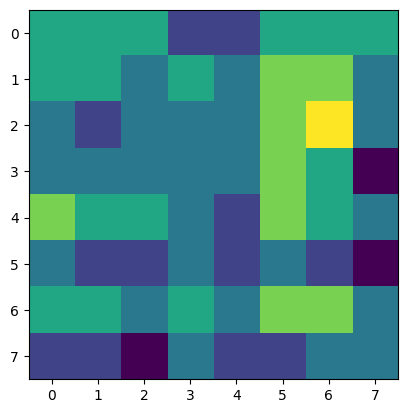

In [29]:
plt.imshow(M[0]@M[1])

plt.show()

In [19]:

for i in range(1):
    print("----------------------",i,"--------------------------")
    M_p = shiftMatrixSystolic(M[0],M[1])
    #Bin = M[1]
    send_matrix(M_p[0],"IMPUT_A",0)
    send_matrix(M_p[1],"IMPUT_B",0)
    
    break
    time.sleep(10)

#send_matrix(Bin)

---------------------- 0 --------------------------
00000001 0
00000010 1
00000011 2
00000110 3
00001011 4
00111110 5
01101100 6
11010010 7
01011010 8
11101000 9
11111000 10
00110000 11
11100000 12
11000000 13
00000000 14
00000001 0
00000010 1
00000001 2
00000000 3
00000000 4
00010111 5
00010110 6
00001110 7
11110110 8
11001100 9
10100000 10
00100000 11
11000000 12
00000000 13
00000000 14


In [20]:
M[0]

array([[1, 0, 1, 1, 0, 1, 1, 0],
       [1, 1, 1, 1, 1, 0, 1, 1],
       [1, 1, 0, 0, 1, 1, 1, 1],
       [0, 1, 0, 1, 1, 0, 1, 1],
       [0, 1, 1, 1, 0, 1, 1, 1],
       [0, 1, 0, 1, 1, 0, 0, 0],
       [1, 1, 1, 1, 1, 0, 1, 1],
       [1, 0, 1, 0, 1, 0, 0, 0]])

In [21]:
M[1]

array([[0, 0, 0, 0, 0, 0, 1, 1],
       [1, 0, 0, 1, 0, 0, 0, 0],
       [1, 1, 0, 1, 0, 0, 0, 1],
       [1, 1, 1, 0, 0, 1, 0, 0],
       [0, 0, 0, 1, 1, 1, 1, 0],
       [1, 0, 1, 0, 0, 1, 1, 1],
       [0, 1, 1, 0, 1, 1, 1, 0],
       [0, 0, 0, 0, 0, 1, 1, 0]])

In [22]:
M[0]@M[1]

array([[3, 3, 3, 1, 1, 3, 3, 3],
       [3, 3, 2, 3, 2, 4, 4, 2],
       [2, 1, 2, 2, 2, 4, 5, 2],
       [2, 2, 2, 2, 2, 4, 3, 0],
       [4, 3, 3, 2, 1, 4, 3, 2],
       [2, 1, 1, 2, 1, 2, 1, 0],
       [3, 3, 2, 3, 2, 4, 4, 2],
       [1, 1, 0, 2, 1, 1, 2, 2]])

In [23]:
s = serial.Serial()

s.port = "/dev/ttyUSB1"
s.baudrate = 115200
s.bytesize = 8
s.close()
s.open()

In [24]:
i =1
s.write(bytearray([int(i)]))


1

In [25]:
serial.Serial()

Serial<id=0x7f8d3cb31060, open=False>(port=None, baudrate=9600, bytesize=8, parity='N', stopbits=1, timeout=None, xonxoff=False, rtscts=False, dsrdtr=False)